# AI: PriceOptima – Dynamic Pricing System
## Milestone 4: Baseline Pricing Engine

## 1. Import Libraries
## 2. Load Processed Dataset

In [ ]:
import pandas as pd

df = pd.read_csv("/content/priceoptima_processed.csv")

df.head()

,Product_ID,City,State,Country,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Ratings,products
0,8691788,Dortmund,Berlin,Germany,Regular,2023-09-18,2023.0,9.0,22:03:55,3.0,108.028757,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,5.0,Cycling shorts
1,2174773,Nottingham,England,UK,Premium,2023-12-31,2023.0,12.0,08:42:04,2.0,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,4.0,Lenovo Tab
2,6679610,Geelong,New South Wales,Australia,Regular,2023-04-26,2023.0,4.0,04:06:29,3.0,354.477600,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,2.0,Sports equipment
3,7232460,Edmonton,Ontario,Canada,Premium,2023-08-05,2023.0,8.0,14:55:17,7.0,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,4.0,Utility knife
4,4983775,Bristol,England,UK,Premium,2024-10-01,2024.0,10.0,16:54:07,2.0,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,1.0,Chocolate cookies


In [ ]:
df = df.rename(columns={
    "Amount": "price",
    "Total_Purchases": "quantity_sold"
})

In [ ]:
print(df.columns)

Index(['Product_ID', 'City', 'State', 'Country', 'Customer_Segment', 'Date',
       'Year', 'Month', 'Time', 'quantity_sold', 'price', 'Total_Amount',
       'Product_Category', 'Product_Brand', 'Product_Type', 'Feedback',
       'Shipping_Method', 'Payment_Method', 'Ratings', 'products'],
      dtype='object')


##3. Simulating Inventory

In [ ]:
import numpy as np

np.random.seed(42)

df["inventory"] = np.random.randint(10,150,size=len(df))

## 4. Time Feature Engineering

In [ ]:
df["hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

## 5. Rule-Based Dynamic Pricing Engine

In [ ]:
def dynamic_price(row):

    price = row["price"]

    # ----- TIME BASED PRICING -----

    # Peak evening demand
    if 18 <= row["hour"] <= 22:
        price *= 1.15

    # Late night demand
    if row["hour"] >= 22 or row["hour"] <= 2:
        price *= 1.10


    # ----- INVENTORY BASED PRICING -----

    if row["inventory"] < 20:
        price *= 1.25

    elif row["inventory"] < 50:
        price *= 1.12

    elif row["inventory"] > 120:
        price *= 0.85


    # ----- DEMAND BASED PRICING -----

    if row["Ratings"] >= 4.5:
        price *= 1.10

    return price

In [ ]:
df["adjusted_price"] = df.apply(dynamic_price, axis=1)

## 6. Revenue Calculation

In [ ]:
df["original_revenue"] = df["price"] * df["quantity_sold"]
df["new_revenue"] = df["adjusted_price"] * df["quantity_sold"]

original_revenue = df["original_revenue"].sum()
new_revenue = df["new_revenue"].sum()

revenue_lift = ((new_revenue - original_revenue) / original_revenue) * 100

In [ ]:
print("Original Revenue:", round(original_revenue,2))
print("Dynamic Revenue:", round(new_revenue,2))
print("Revenue Lift (%):", round(revenue_lift,2))

Original Revenue: 256279044.32
Dynamic Revenue: 277144277.49
Revenue Lift (%): 8.14


## 7. Revenue Comparison Visualization

In [ ]:
comparison = df[[
    "price",
    "adjusted_price",
    "quantity_sold",
    "inventory",
    "hour"
]].head(10)

comparison

,price,adjusted_price,quantity_sold,inventory,hour
0,108.028757,150.322015,3.0,112,22.0
1,403.353907,403.353907,2.0,102,8.0
2,354.477600,397.014912,3.0,24,4.0
3,352.407717,352.407717,7.0,116,14.0
4,124.276524,124.276524,2.0,81,16.0
5,296.291806,365.031505,4.0,30,23.0
6,315.057648,315.057648,2.0,112,13.0
7,46.588070,39.599860,1.0,131,10.0
8,328.839302,328.839302,8.0,84,14.0
9,397.611229,502.978205,10.0,97,22.0


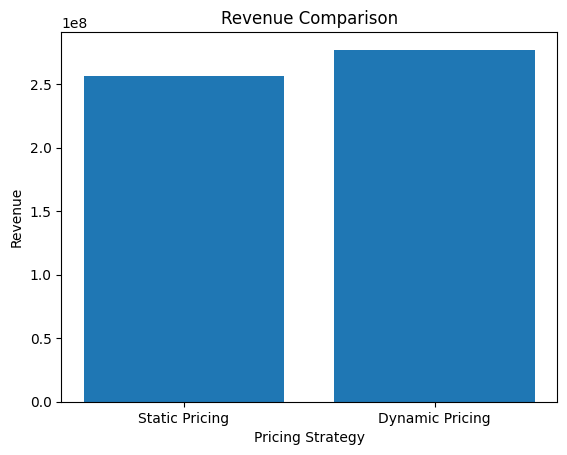

In [ ]:
import matplotlib.pyplot as plt

labels = ["Static Pricing", "Dynamic Pricing"]
values = [original_revenue, new_revenue]

plt.bar(labels, values)
plt.title("Revenue Comparison")
plt.ylabel("Revenue")
plt.xlabel("Pricing Strategy")

plt.show()

The baseline pricing engine adjusts product prices using rule-based logic based on time of purchase, inventory levels, and product demand (ratings).
Compared to static pricing, the dynamic pricing strategy improves revenue by increasing prices during high demand and reducing prices when inventory is high.